# Feature Selection & PCA
**ShipmentSure — Predicting On-Time Delivery**

Not all features are useful. We identify and keep only the important ones:
- SelectKBest with ANOVA F-test for top features
- PCA for dimensionality reduction
- RandomForest feature importances for validation

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid")
print("Libraries loaded.")

Libraries loaded.


In [26]:
df = pd.read_csv('../data/Train.csv')
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)

# One-hot encode for feature selection
df_encoded = pd.get_dummies(df, drop_first=True)
print(f"Encoded shape: {df_encoded.shape}")
df_encoded.head()

Encoded shape: (1000, 16)


,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_low,Product_importance_medium,Gender_M
0,2,5,306,6,45,3838,1,False,True,False,False,False,False,False,False,True
1,7,2,114,3,35,2710,1,False,False,False,True,False,True,False,False,True
2,7,2,215,7,44,4152,0,True,False,False,False,False,True,False,True,False
3,5,3,126,5,54,2245,0,False,False,False,False,True,False,False,True,True
4,3,5,113,3,43,1806,1,False,False,False,True,False,True,False,True,True


In [27]:
# Separate features and target
X = df_encoded.drop('Reached.on.Time_Y.N', axis=1)
y = df_encoded['Reached.on.Time_Y.N']
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (1000, 15), y shape: (1000,)


In [28]:
# SelectKBest with ANOVA F-test
selector = SelectKBest(f_classif, k=5)
X_selected = selector.fit_transform(X, y)

# Get selected feature names
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]
scores = selector.scores_[selected_mask]

print("Top 5 features (SelectKBest):")
for feat, score in sorted(zip(selected_features, scores), key=lambda x: -x[1]):
    print(f"  {feat}: F-score = {score:.2f}")

Top 5 features (SelectKBest):
  Weight_in_gms: F-score = 3.25
  Product_importance_medium: F-score = 1.87
  Mode_of_Shipment_Ship: F-score = 1.74
  Warehouse_block_F: F-score = 1.62
  Customer_care_calls: F-score = 1.21


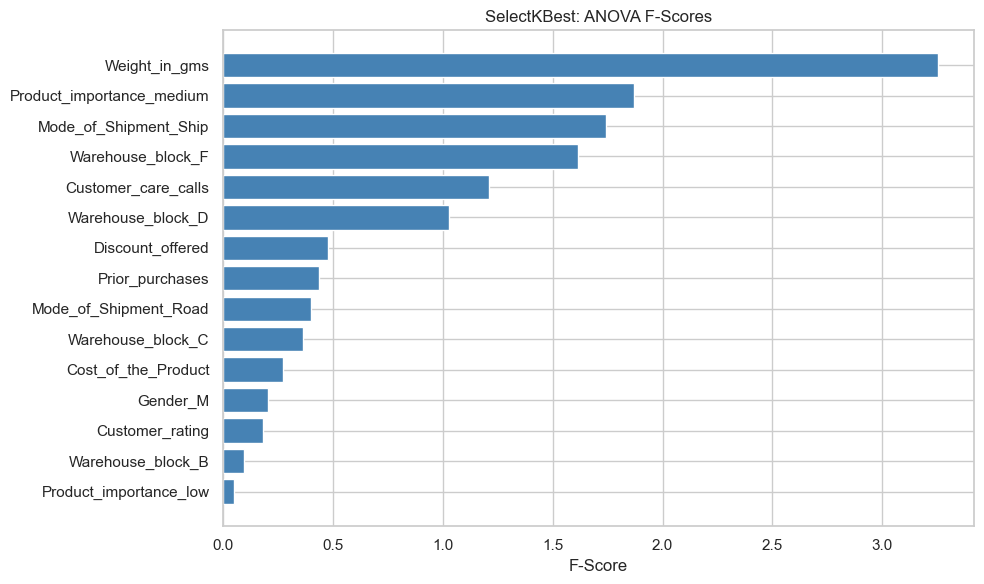

In [29]:
# Bar chart of all feature scores
all_scores = pd.DataFrame({'Feature': X.columns, 'F_Score': selector.scores_})
all_scores = all_scores.sort_values('F_Score', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(all_scores['Feature'], all_scores['F_Score'], color='steelblue')
plt.title('SelectKBest: ANOVA F-Scores')
plt.xlabel('F-Score')
plt.tight_layout()
plt.show()

In [30]:
# PCA for dimensionality reduction
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA reduced shape: {X_pca.shape}")
print(f"Explained variance: {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

PCA reduced shape: (1000, 2)
Explained variance: [0.103 0.103]
Total variance explained: 20.63%


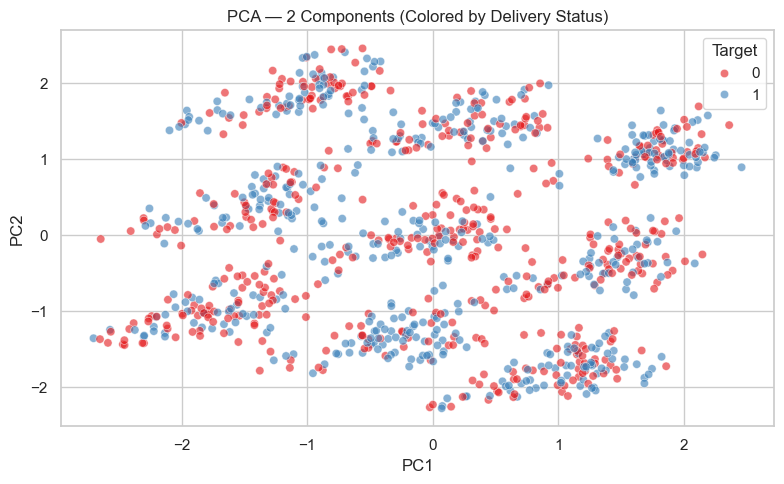

In [31]:
# Visualize PCA components
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Target'] = y.values

plt.figure(figsize=(8, 5))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Target', alpha=0.6, palette='Set1')
plt.title('PCA — 2 Components (Colored by Delivery Status)')
plt.tight_layout()
plt.show()

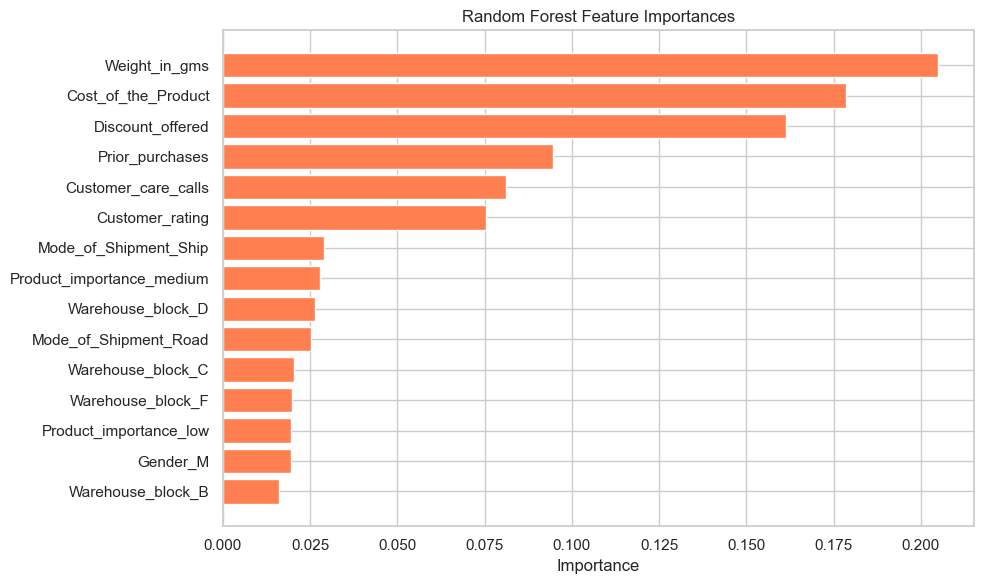

Top 5 most important features:
            Feature  Importance
      Weight_in_gms    0.204950
Cost_of_the_Product    0.178557
   Discount_offered    0.161314
    Prior_purchases    0.094666
Customer_care_calls    0.081042


In [32]:
# Validate with RandomForest feature importances
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X, y)

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='coral')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(feat_imp.tail(5).iloc[::-1][['Feature', 'Importance']].to_string(index=False))